In [8]:
import zipfile

zip_path = "/lustre09/project/6081099/reem2005/DATASET/UCI HAR Dataset.zip"
extract_path = "/lustre09/project/6081099/reem2005/DATASET/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [11]:
import pandas as pd

DATA_PATH = "/lustre09/project/6081099/reem2005/DATASET/UCI HAR Dataset/"

# Features
X_train = pd.read_csv(
    DATA_PATH + "train/X_train.txt",
    sep=r"\s+",
    header=None
).values

X_test = pd.read_csv(
    DATA_PATH + "test/X_test.txt",
    sep=r"\s+",
    header=None
).values

# Labels
y_train = pd.read_csv(
    DATA_PATH + "train/y_train.txt",
    header=None
).values.ravel()

y_test = pd.read_csv(
    DATA_PATH + "test/y_test.txt",
    header=None
).values.ravel()

# Activity names
activity_labels = pd.read_csv(
    DATA_PATH + "activity_labels.txt",
    sep=r"\s+",
    header=None
)

LABELS = activity_labels[1].tolist()

# Convert labels from 1-6 to 0-5
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Activities:", LABELS)

X_train: (7352, 561)
X_test : (2947, 561)
y_train: (7352,)
y_test : (2947,)
Activities: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [ ]:
Machine Learning Models - UCI HAR

In [12]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In this section, Logistic Regression is trained using GridSearchCV to find the optimal hyperparameters. The best model is then evaluated on the test set using multiple performance metrics.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000),
        {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "saga"]
        },
        X_train_scaled,
        X_test_scaled
    ),

    "SVM": (
        SVC(),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        },
        X_train_scaled,
        X_test_scaled
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 10, 20]
        },
        X_train,
        X_test
    )
}

results = []
best_models = {}
for model_name, (model, params, Xtr, Xte) in models.items():

    print("=" * 60)
    print(model_name)

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(Xtr, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(Xte)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1-score": f1_score(y_test, y_pred, average="macro")
    })

    best_models[model_name] = {
        "model": best_model,
        "prediction": y_pred
    }

    print("Best Parameters:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression


/home/reem2005/.local/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/reem2005/.local/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/reem2005/.local/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/reem2005/.local/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/reem2005/.local/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/reem2005/.local/lib/python3.11/site-packages/sklearn/linear_mode

Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Accuracy: 0.9552086868001357
SVM
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy: 0.9616559212758737
Random Forest
Best Parameters: {'max_depth': None, 'n_estimators': 300}
Accuracy: 0.9287410926365796


In [17]:
results_df = pd.DataFrame(results)

results_df.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
1,SVM,0.961656,0.963449,0.960653,0.961508
0,Logistic Regression,0.955209,0.958033,0.953848,0.955014
2,Random Forest,0.928741,0.930053,0.925837,0.927066


## Model Comparison

The performance of all machine learning models is summarized below using Accuracy, Precision, Recall, and F1-score.

In [18]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.961656,0.963449,0.960653,0.961508
1,Logistic Regression,0.955209,0.958033,0.953848,0.955014
2,Random Forest,0.928741,0.930053,0.925837,0.927066


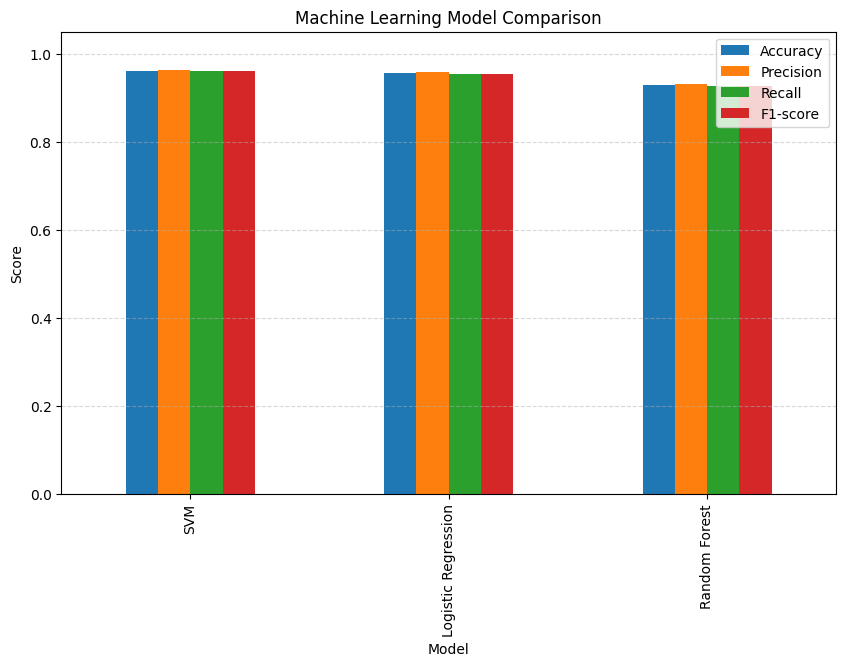

In [19]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Machine Learning Model Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [21]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: SVM


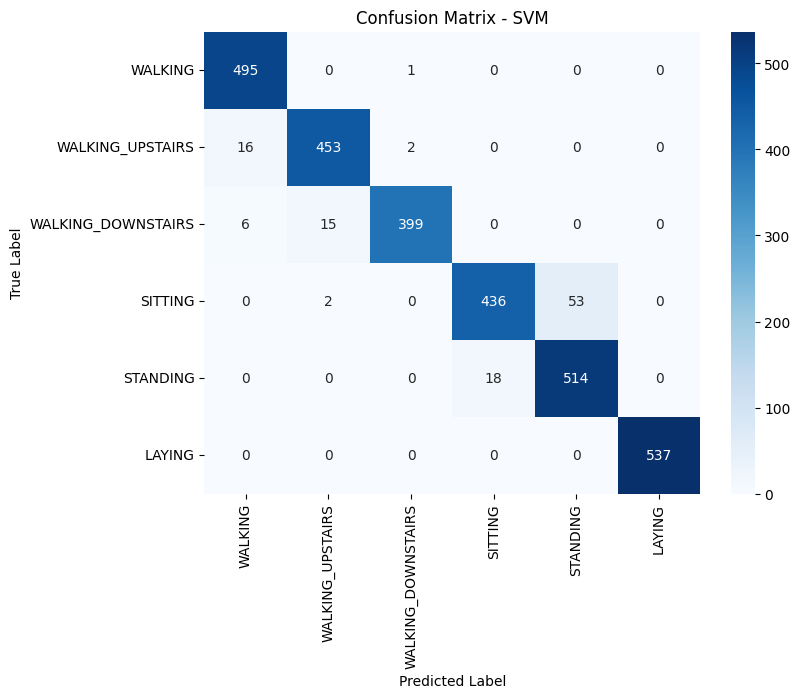

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = best_models[best_model_name]["prediction"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()